# Korea FCFF DCF Valuation v1
## Sales-driven FCFF 모델 기반 한국 주식 내재가치 계산

### 처리 흐름
```
①  korea_fs_data_from_DG    → 과거 매출 + IS / BS / CF 분기 데이터
②  korea_revenue_forecast_result → 8분기 매출 예측 (SARIMA/ETS/Theta/Ensemble)
③  Sales-driven 회귀
      OPM  = f(Sales)      [SARIMA/ETS/Theta Ensemble 예측]
      D&A  = α × Sales     [OLS 또는 median ratio fallback]
      CapEx = β × Sales    [동일]
      NWC   = γ × Sales    [동일, 한국 BS 보완 산식]
④  3-Stage DCF
      Phase 1 (Y1-2)  : DB 예측 FCFF
      Phase 2 (Y3-Yn) : EVA-based moat → AR(1) decay
      Phase 3 (Y∞)    : Terminal Value
⑤  WACC = Re×E/V + Rd×(1-t)×D/V
      Re : CAPM = Rf(BOK 10Y 국고채) + β_blume × ERP
      ERP: Damodaran 한국 ERP 7% (또는 KOSPI 10년 기하평균, floor 7%)
⑥  결과 → korea_fcff_dcf_valuation 테이블 (날짜별 누적)
⑦  데이터 품질 → korea_valuation_quality_log
```

### v1 핵심 설계 결정 (호영님과 합의)
| # | 결정 | 적용 |
|---|---|---|
| 1 | DataGuide item_code | FCFF_RIM_DATA.xlsx 헤더에서 추출한 35개 매핑 |
| 2 | 매출예측 | korea_revenue_forecast_result, indicator=model명, created_at=예측일 |
| 3 | KOSPI | FinanceDataReader 'KS11' |
| 4 | ERP | Damodaran 7% 기본 / KOSPI geo 10y (floor 7%) 옵션 |
| 5 | 결측 처리 | 핵심항목(매출/영업이익) 결측 → 제외, 보조(D&A/CapEx) → median fallback |

### 학술 근거
- 3-Stage 구조 : Damodaran (2002) Investment Valuation Ch.12
- AR(1) decay : Fama-French (1995) JF, Ohlson (1995), Feltham-Ohlson
- Moat → CAP : Mauboussin & Johnson (1997) FAJ
- Blume β    : Blume (1971) JF — β_adj = 0.67×β + 0.33×1.0


## Cell 1 · 경로 자동 감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for cand in _CANDIDATE_ROOTS:
        if os.path.isdir(cand) and os.path.isdir(os.path.join(cand, "DATA")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            print(f"[PATH] root 후보 경로 : {cand}")
            return cand
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS 를 환경에 맞게 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

> **여기만 수정하면 됩니다**:
> - `TICKER_START / TICKER_END / SKIP_DONE`
> - `ERP_METHOD` ('damodaran_floor' or 'kospi_geo_10y')
> - `MIN_REVENUE_QUARTERS` (기본 24분기 = 6년)


In [2]:
# ── 표준 라이브러리 ──────────────────────────────────────────────
import gc, math, time, traceback, warnings
from datetime import datetime, date, timedelta
from typing import Optional, Dict, Any, List, Tuple

# ── 외부 라이브러리 ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

# ── 내부 모듈 ────────────────────────────────────────────────────
from DATA.config import get_db_info, get_engine
from DATA.KEYS import KEYS
from DATA.korea_valuation_helpers import (
    setup_project_path, to_dg_ticker, to_price_ticker, get_pymysql_conn,
    DG_ITEM_CODES, get_item_code,
    load_korea_financials_wide, load_korea_revenue_forecast,
    load_korea_marketcap_latest, load_korea_price_series, load_current_price,
    load_kospi_series, get_risk_free_rate, compute_beta_10y,
    estimate_market_return, get_universe_with_min_history,
    DataQualityReport, save_quality_report_to_db, get_evaluation_history,
)
from DATA.universal_ts_forecast_function_v2 import (
    forecast_sarima, forecast_ets, forecast_theta,
    infer_freq_alias, seasonal_periods_from_freq, clear_memory,
)

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  설정 상수 — 여기만 수정하세요
# ══════════════════════════════════════════════════════════════════

# DB 테이블
TABLE_FS         = "korea_fs_data_from_DG"
TABLE_FORECAST   = "korea_revenue_forecast_result"
TABLE_MARKETCAP  = "ks_listed_company_daily_marketcap"
TABLE_PRICE      = "KSE_Price"
TABLE_RESULT     = "korea_fcff_dcf_valuation"
TABLE_QUALITY    = "korea_valuation_quality_log"

# 모델 파라미터
FORECAST_HORIZON   = 8        # 예측 분기 수 (2년)
MIN_HISTORY        = 16       # OPM 회귀 최소 분기 수
MIN_REVENUE_QUARTERS = 24     # universe 필터: 최소 24분기(6년) 매출 보유
WINSORIZE_LIMITS   = (0.05, 0.95)
GDP_GROWTH         = 0.025    # 한국 장기 GDP 성장률 추정 (terminal cap)

# OLS fallback 기준
OLS_MIN_R2         = 0.30
OLS_MIN_SAMPLES    = 16

# WACC 관련
ERP_METHOD          = "damodaran_floor"  # 'damodaran_floor' | 'kospi_geo_10y' | 'kospi_geo_no_floor'
DAMODARAN_ERP_KR    = 0.07               # Damodaran 한국 ERP (호영님 기본)
GEO_FLOOR           = 0.07               # KOSPI geo 사용 시 E(Rm) floor
RF_FALLBACK         = 0.035              # BOK API 실패 시 fallback Rf
RD_DEFAULT          = 0.045              # 부채비용 기본값 (이자비용/총부채 계산 실패 시)
WACC_FLOOR          = 0.05
WACC_CAP            = 0.20

# Net Debt / Total Debt 합산 항목 (BS 컬럼 키)
DEBT_KEYS = ["short_term_debt", "current_lt_debt", "bonds",
             "long_term_debt", "lease_liab"]
CASH_KEYS = ["cash", "short_term_invest"]

# 시가총액 단위 환산: DataGuide 시총이 백만원 단위라고 가정
# (단위 확인 필요 — 삼성전자 시총 약 500조 = 500,000,000 (백만원) = 5,000,000 (억원))
MARKETCAP_UNIT_MULTIPLIER = 1_000_000  # 백만원 → 원

# 재무데이터 단위: DataGuide value=천원 → 원으로 환산
FS_UNIT_MULTIPLIER = 1_000  # 천원 → 원

# 배치 범위
TICKER_START = 0
TICKER_END   = 9999
SKIP_DONE    = False

# 체크포인트
CHECKPOINT_DIR = "_korea_fcff_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료")
print(f"[설정] FORECAST_HORIZON={FORECAST_HORIZON}Q  ERP_METHOD={ERP_METHOD}")
print(f"[설정] MIN_REVENUE_QUARTERS={MIN_REVENUE_QUARTERS}  GDP_GROWTH={GDP_GROWTH}")
print(f"[설정] WACC 범위 [{WACC_FLOOR:.0%}, {WACC_CAP:.0%}]")


[OK] Import 완료
[설정] FORECAST_HORIZON=8Q  ERP_METHOD=damodaran_floor
[설정] MIN_REVENUE_QUARTERS=24  GDP_GROWTH=0.025
[설정] WACC 범위 [5%, 20%]


## Cell 3 · DB 연결 & 결과 테이블 초기화

`korea_fcff_dcf_valuation` 테이블 (없으면 생성):
- PK = (ticker, date, quarter) → 같은 종목의 같은 평가일자 + 같은 분기는 갱신
- 평가일자(date)가 다르면 별도 row → 시계열 추적 가능


In [3]:
# ── 결과 테이블 생성 (없으면) ─────────────────────────────────
CREATE_SQL = f"""
CREATE TABLE IF NOT EXISTS `{TABLE_RESULT}` (
  `id`                BIGINT      NOT NULL AUTO_INCREMENT,
  `date`              DATE        NOT NULL COMMENT '평가 실행일',
  `ticker`            VARCHAR(20) NOT NULL COMMENT 'A005930 형식',
  `quarter`           VARCHAR(10)          COMMENT 'e.g. 2026Q1',
  `sales_actual`      DOUBLE               COMMENT '과거 Sales (원)',
  `sales_forecast`    DOUBLE               COMMENT '예측 Sales (원)',
  `opm_forecast`      DOUBLE,
  `ebit`              DOUBLE,
  `tax_rate`          DOUBLE,
  `nopat`             DOUBLE,
  `da`                DOUBLE,
  `capex`             DOUBLE,
  `nwc`               DOUBLE,
  `delta_nwc`         DOUBLE,
  `fcff`              DOUBLE,
  `roic`              DOUBLE,
  `reinvestment_rate` DOUBLE,
  `g_terminal`        DOUBLE,
  `discount_rate`     DOUBLE COMMENT 'WACC',
  `wacc_re`           DOUBLE COMMENT 'Cost of Equity',
  `wacc_rd`           DOUBLE COMMENT 'Cost of Debt',
  `beta_raw`          DOUBLE,
  `beta_blume`        DOUBLE,
  `enterprise_value`  DOUBLE,
  `net_debt`          DOUBLE,
  `equity_value`      DOUBLE,
  `shares`            DOUBLE,
  `target_price`      DOUBLE,
  `current_price`     DOUBLE,
  `upside_pct`        DOUBLE,
  `moat_label`        VARCHAR(30),
  `eva_spread`        DOUBLE,
  `revenue_quarters`  INT COMMENT '사용된 매출 분기 수',
  `forecast_model`    VARCHAR(20) COMMENT 'Sales 예측 모델명',
  `forecast_date`     DATE COMMENT '매출 예측 실행일',
  `created_at`        DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `quarter`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
finally:
    conn.close()

# 연결 테스트
try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공 host={db_info.get('host')} port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

# Universe 미리 조회
universe_df = get_universe_with_min_history(
    db_info, min_quarters=MIN_REVENUE_QUARTERS, require_consecutive=False
)
KOREA_TICKER_LIST = universe_df["ticker"].tolist()
print(f"\n[Universe] 매출 ≥{MIN_REVENUE_QUARTERS}분기 종목: {len(KOREA_TICKER_LIST):,}개")
print(f"  최장 보유: {universe_df['n_quarters'].max()}분기")
print(f"  평균 결측 분기: {universe_df['gap_count'].mean():.1f}")
display(universe_df.head(10))


[23:11:57][DB] 테이블 준비 완료: korea_fcff_dcf_valuation
[23:11:57][DB] 연결 성공 host=192.168.0.230 port=3307

[Universe] 매출 ≥24분기 종목: 1,267개
  최장 보유: 66분기
  평균 결측 분기: 0.3


,ticker,n_quarters,first_date,last_date,gap_count
0,A002320,66,2009-12-30,2026-03-31,0
1,A005930,66,2009-12-30,2026-03-31,0
2,A039840,66,2009-12-30,2026-03-31,0
3,A052400,66,2009-12-30,2026-03-31,0
4,A066570,66,2009-12-30,2026-03-31,0
5,A046890,66,2009-12-30,2026-03-31,0
6,A059090,65,2009-12-30,2025-12-30,0
7,A060250,65,2009-12-30,2025-12-30,0
8,A063570,65,2009-12-30,2025-12-30,0
9,A065530,65,2009-12-30,2025-12-30,0


## Cell 4 · 시장 파라미터 (Rf, KOSPI, E(Rm)) — 1회 계산 후 캐싱

배치 시작 전에 **시장 공통 파라미터** 계산해서 모든 종목이 공유:
- `RF`         : BOK API → 10Y 국고채 (실시간)
- `KOSPI_PX`   : FDR → KOSPI 종합지수 (베타·E(Rm) 계산용)
- `E_Rm`, `ERP`: Damodaran 또는 KOSPI geo 10y


In [4]:
# 1. Risk-free rate (BOK API)
RF, RF_SOURCE = get_risk_free_rate(KEYS["BOK"], fallback_rate=RF_FALLBACK)
log("MKT", f"Rf = {RF:.4%}  (source: {RF_SOURCE})")

# 2. KOSPI 시계열 (12년치 → 베타·E(Rm) 모두 사용)
KOSPI_PX = load_kospi_series(start_date=(datetime.today() - timedelta(days=365*12)).strftime("%Y-%m-%d"))
log("MKT", f"KOSPI {len(KOSPI_PX):,}거래일  ({KOSPI_PX.index.min().date()} ~ {KOSPI_PX.index.max().date()})")
log("MKT", f"  현재 KOSPI = {KOSPI_PX.iloc[-1]:,.2f}")

# 3. E(Rm) 추정
mkt = estimate_market_return(
    method=ERP_METHOD, rf=RF, kospi_series=KOSPI_PX,
    years=10, damodaran_erp_kr=DAMODARAN_ERP_KR, geo_floor=GEO_FLOOR,
)
E_RM = mkt["e_rm"]
ERP  = mkt["erp"]
log("MKT", f"E(Rm) = {E_RM:.4%}  ERP = {ERP:.4%}")
log("MKT", f"  → {mkt['note']}")
if mkt["kospi_geo"] is not None:
    log("MKT", f"  (참고) KOSPI 10년 기하평균 = {mkt['kospi_geo']:.4%}")

print()
print("=" * 60)
print(f"  Rf  = {RF:>7.3%}    (BOK 10Y 국고채)")
print(f"  ERP = {ERP:>7.3%}    (방식: {ERP_METHOD})")
print(f"  E(Rm) = {E_RM:>7.3%}")
print("=" * 60)


[23:12:03][MKT] Rf = 3.6550%  (source: BOK_2026-04-21)
[KOSPI] try source=fdr (2014-04-24 ~ 2026-04-21) ... FAIL (FDR 실패 (재시도 3회): LOGOUT)
[KOSPI] try source=pykrx (2014-04-24 ~ 2026-04-21) ... FAIL ('지수명')
[KOSPI] try source=yfinance (2014-04-24 ~ 2026-04-21) ... OK  2,936거래일
[23:12:16][MKT] KOSPI 2,936거래일  (2014-04-24 ~ 2026-04-20)
[23:12:16][MKT]   현재 KOSPI = 6,219.09
[23:12:16][MKT] E(Rm) = 10.6550%  ERP = 7.0000%
[23:12:16][MKT]   → Damodaran 한국 ERP 7.0% 적용
[23:12:16][MKT]   (참고) KOSPI 10년 기하평균 = 11.9825%

  Rf  =  3.655%    (BOK 10Y 국고채)
  ERP =  7.000%    (방식: damodaran_floor)
  E(Rm) = 10.655%


## Cell 5 · KoreaDCFModel 클래스

US v7 `DCFModel` 의 한국화 버전. 핵심 차이:
- 데이터 소스: FMP API → DataGuide DB (`korea_fs_data_from_DG`)
- WACC: FMP shares/marketcap → KSE_Price + ks_listed_company_daily_marketcap
- 베타: 사전계산 X → KSE_Price 일별수익률 vs KOSPI (10년 회귀, Blume 조정)
- NWC: 한국 BS에 유동부채 컬럼 없으므로 (Receivables+Inventories) - (Short-term debts) 근사
- 데이터 품질: 모든 fallback을 `DataQualityReport` 로 추적


[OK] KoreaDCFModel 클래스 & process_one_ticker_kr 정의 완료

[테스트] A004000 단일 실행 ...
[00:02:03][A004000] Sales actual=65Q forecast=8Q model=Ensemble created_at=2026-04-21 00:00:00
[00:02:03][A004000] FS wide  shape=(67, 35)  기간=2009-12-31 ~ 2026-06-30
[메모리] forecast_sarima 실행 전: 523.09 MB
[메모리] find_best_sarima_params 실행 전: 523.09 MB
[메모리] find_best_sarima_params 실행 후: 517.12 MB (변화: -5.96 MB)
[메모리] forecast_sarima 실행 후: 517.12 MB (변화: -5.96 MB)
[메모리] forecast_ets 실행 전: 517.12 MB
[메모리] forecast_ets 실행 후: 517.14 MB (변화: +0.02 MB)
[메모리] forecast_theta 실행 전: 517.14 MB
[메모리] forecast_theta 실행 후: 517.14 MB (변화: +0.00 MB)
[00:02:17][A004000] β_raw=0.863 β_blume=0.908  Re=10.0110%  (n=2450, R²=0.21)
[00:02:21][A004000] WACC=10.0110%  Re=10.0110% Rd=1.0045% tax=20.2966%  E/V=100.00% D/V=0.00%  E=1.33조 D=0.00조
[00:02:24][A004000] 3-Stage  EV=0.25조  TP=9,951원  CP=54,400원  Up=-81.7%  TV비중=52.2%  Moat=No moat

  status=ok  msg=TP=9,951원

────────────────────────────────────────────────────────────
데이터 품질

,field,status,n_obs,value,r2,note
0,revenue_actual,ok,65,NaN,NaN,
1,revenue_forecast,ok,8,NaN,NaN,"model=Ensemble, created_at=2026-04-21 00:00:00"
2,operating_income,ok,65,NaN,NaN,
3,tax_rate,ok,55,0.202966,NaN,
4,opm_forecast,ok,65,NaN,NaN,"models=['SARIMA', 'ETS', 'Theta']"
5,da,fallback_median,65,0.061462,0.063952,"OLS R²=0.06 → median, cols=['da_cf', 'intangib..."
6,capex,fallback_median,65,0.080258,0.021769,"OLS R²=0.02 → median, cols=['capex_tangible', ..."
7,nwc,ok,65,1.194105,0.592770,(Recv+Inv) - (ST debts) ratio
8,beta,ok,2450,0.907994,0.210141,β_raw=0.863 → blume=0.908
9,tax_rate,ok,55,0.202966,NaN,


[메모리] forecast_sarima 실행 전: 517.14 MB
[메모리] find_best_sarima_params 실행 전: 517.14 MB
[메모리] find_best_sarima_params 실행 후: 517.14 MB (변화: +0.00 MB)
[메모리] forecast_sarima 실행 후: 517.14 MB (변화: +0.00 MB)
[메모리] forecast_ets 실행 전: 517.14 MB
[메모리] forecast_ets 실행 후: 517.14 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 517.14 MB
[메모리] forecast_theta 실행 후: 517.14 MB (변화: +0.00 MB)


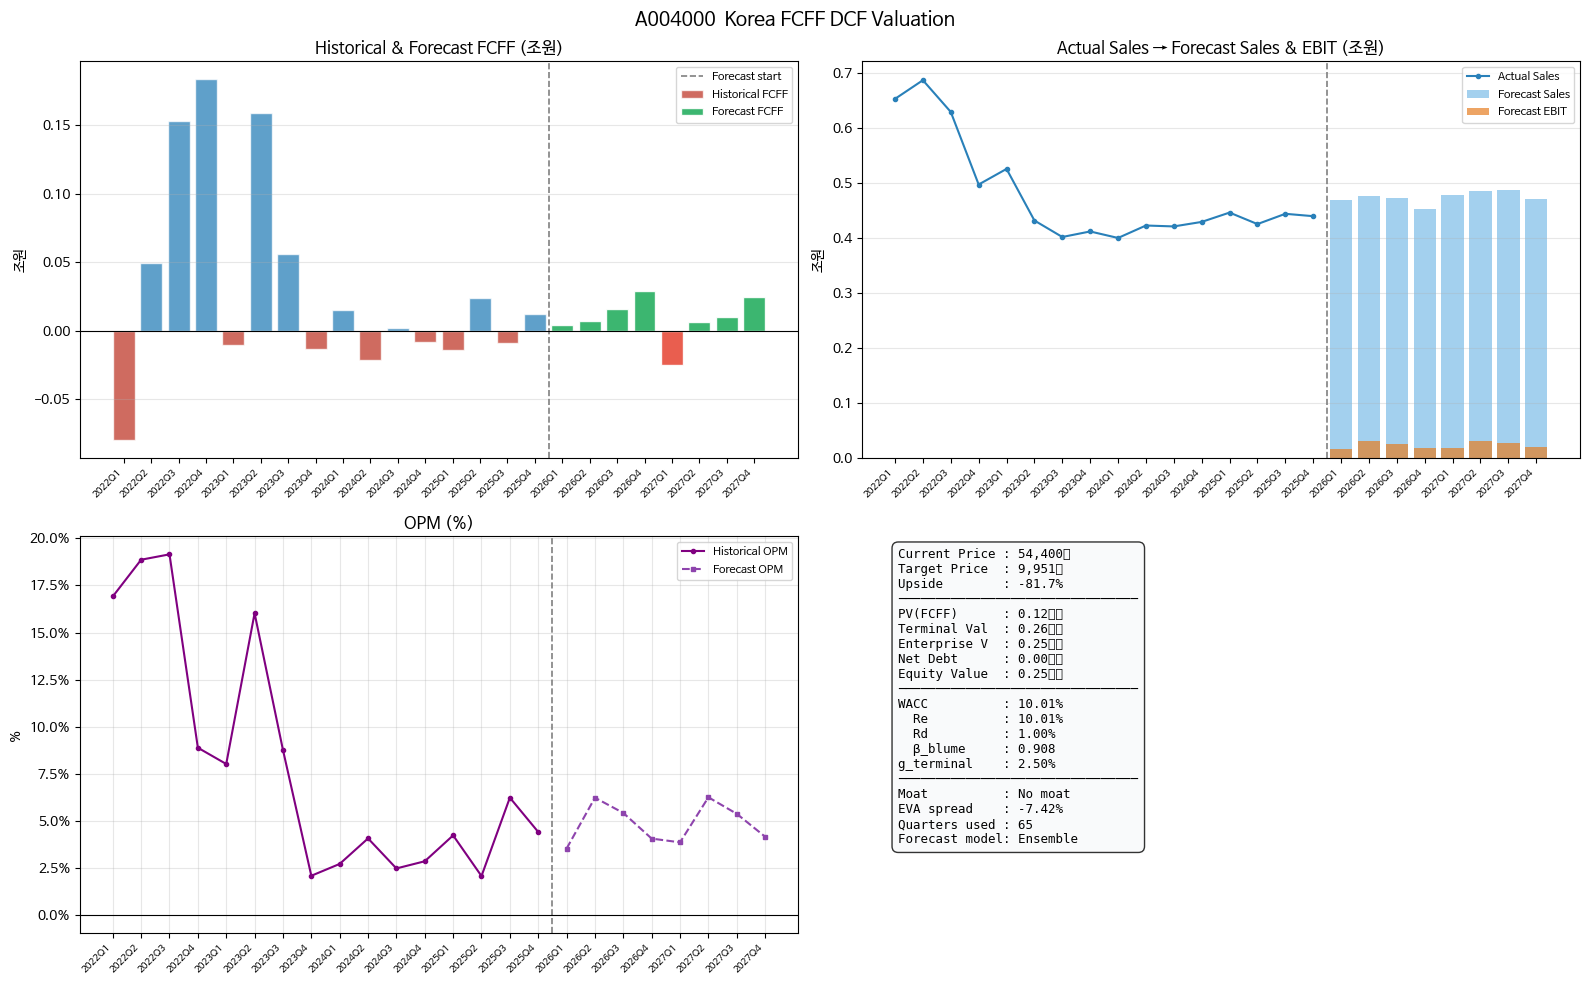

In [36]:
# ═══════════════════════════════════════════════════════════════
#  KoreaDCFModel  —  한국 주식 Sales-driven FCFF DCF
# ═══════════════════════════════════════════════════════════════

class KoreaDCFModel:
    """
    한국 기업 FCFF DCF Valuation Model.

    사용 흐름:
        m = KoreaDCFModel(ticker="A005930", engine=engine, db_info=db_info,
                          rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=True)
        m.run()
        m.save_to_db("2026-04-21")
        m.plot()

    핵심 차이 (vs US v7):
      - FMP API 호출 없음 → 모두 DB 조회
      - 자체 베타 계산 (KSE_Price + KOSPI 일별수익률 10년 회귀, Blume)
      - NWC ≈ Receivables + Inventories - Short-term debts  (한국 BS 보완)
      - DataQualityReport 로 모든 fallback 추적
    """

    def __init__(self, ticker, engine, db_info,
                 rf, e_rm, kospi_series,
                 forecast_horizon=FORECAST_HORIZON,
                 min_history=MIN_HISTORY,
                 gdp_growth=GDP_GROWTH,
                 verbose=False):
        self.ticker_dg     = to_dg_ticker(ticker)
        self.ticker_price  = to_price_ticker(ticker)
        self.engine        = engine
        self.db_info       = db_info
        self.rf            = rf
        self.e_rm          = e_rm
        self.erp           = e_rm - rf
        self.kospi         = kospi_series
        self.horizon       = forecast_horizon
        self.min_history   = min_history
        self.gdp_growth    = gdp_growth
        self.verbose       = verbose

        # 데이터 저장소
        self._sales_actual: Optional[pd.Series]   = None
        self._sales_forecast: Optional[pd.Series] = None
        self._used_model: str                     = ""
        self._forecast_date: Optional[date]       = None
        self._fs_wide: Optional[pd.DataFrame]     = None  # IS+BS+CF wide-form
        self._stock_data: Optional[pd.DataFrame]  = None
        self._fcff_history: Optional[pd.Series]   = None
        self._beta_info: Optional[Dict]           = None
        self._mkt_cap: Optional[float]            = None
        self._current_price: Optional[float]      = None

        self.result_df: Optional[pd.DataFrame]    = None
        self.valuation: Optional[Dict]            = None
        self.report = DataQualityReport(ticker=self.ticker_dg)

    # ─────────────────────────────────────────────────────────
    # 1. 데이터 로드
    # ─────────────────────────────────────────────────────────

    def load_sales(self):
        """매출 actual + forecast 로드. 핵심항목이라 결측 시 즉시 raise."""
        # Actual
        wide = load_korea_financials_wide(
            self.ticker_dg, self.db_info, table_name=TABLE_FS,
            item_keys=["revenue"], fillna_zero=False,
        )
        actual = wide["revenue"].dropna() * FS_UNIT_MULTIPLIER  # 천원 → 원
        if actual.empty:
            self.report.add("revenue_actual", "missing", n_obs=0,
                            note="korea_fs_data_from_DG에 매출 데이터 없음")
            raise ValueError(f"[{self.ticker_dg}] Sales actual 데이터 없음")

        if len(actual) < MIN_REVENUE_QUARTERS:
            self.report.add("revenue_actual", "missing", n_obs=len(actual),
                            note=f"매출 {len(actual)}분기 < 최소 {MIN_REVENUE_QUARTERS}")
            raise ValueError(
                f"[{self.ticker_dg}] 매출 {len(actual)}분기 < 최소 {MIN_REVENUE_QUARTERS}분기"
            )
        self.report.add("revenue_actual", "ok", n_obs=len(actual))

        # Forecast
        forecast, model_name, ca = load_korea_revenue_forecast(
            self.ticker_dg, self.db_info, table_name=TABLE_FORECAST,
            horizon=self.horizon,
        )
        if forecast.empty:
            self.report.add("revenue_forecast", "missing", n_obs=0,
                            note="korea_revenue_forecast_result에 예측 없음")
            raise ValueError(
                f"[{self.ticker_dg}] 매출 forecast 없음 — Korea_revenue_forecast 먼저 실행"
            )
        forecast = forecast * FS_UNIT_MULTIPLIER  # 천원 → 원
        self.report.add("revenue_forecast", "ok", n_obs=len(forecast),
                        note=f"model={model_name}, created_at={ca}")

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        self._used_model     = model_name
        self._forecast_date  = ca

        if self.verbose:
            log(self.ticker_dg,
                f"Sales actual={len(actual)}Q forecast={len(self._sales_forecast)}Q "
                f"model={model_name} created_at={ca}")
        return self

    def load_financials(self):
        """IS / BS / CF wide-form + 주식수 로드."""
        # 재무 항목 wide-form
        wide = load_korea_financials_wide(
            self.ticker_dg, self.db_info, table_name=TABLE_FS,
            item_keys=None,  # 전체
            fillna_zero=False,
        )
        if wide.empty:
            raise ValueError(f"[{self.ticker_dg}] 재무 데이터 wide-form 비어있음")

        # 단위 변환: 천원 → 원 (주식수만 제외)
        non_share_cols = [c for c in wide.columns
                          if c not in ("shares_treasury_adj", "shares_common")]
        wide[non_share_cols] = wide[non_share_cols] * FS_UNIT_MULTIPLIER

        # 핵심항목 검증 (영업이익은 필수)
        if "operating_income" not in wide.columns or wide["operating_income"].dropna().empty:
            self.report.add("operating_income", "missing", n_obs=0,
                            note="영업이익 데이터 없음 — 가치평가 불가")
            raise ValueError(f"[{self.ticker_dg}] operating_income 데이터 없음")
        self.report.add("operating_income", "ok",
                        n_obs=int(wide["operating_income"].notna().sum()))

        self._fs_wide = wide
        if self.verbose:
            log(self.ticker_dg, f"FS wide  shape={wide.shape}  "
                f"기간={wide.index.min().date()} ~ {wide.index.max().date()}")
        return self

    # ─────────────────────────────────────────────────────────
    # 2. 변수별 추정
    # ─────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s, limits=WINSORIZE_LIMITS):
        s = s.dropna()
        if len(s) < 4:
            return s
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x, y):
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0, int(mask.sum())
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return float(slope), float(r ** 2), int(mask.sum())

    def estimate_tax_rate(self):
        """실효세율 (pretaxIncome > 0 분기, clip 0~40%, 한국 법정세율 22% fallback)"""
        df = self._fs_wide[["pretax_income", "tax_expense"]].dropna()
        df = df[df["pretax_income"] > 0]
        if df.empty:
            self.report.add("tax_rate", "fallback_zero", n_obs=0,
                            value=0.22, note="법정세율 22% fallback")
            return 0.22
        rates = (df["tax_expense"] / df["pretax_income"]).clip(0, 0.40)
        med = float(rates.median())
        self.report.add("tax_rate", "ok", n_obs=len(rates), value=med)
        return med

    def estimate_opm(self, sales_series):
        """OPM 예측: SARIMA/ETS/Theta Ensemble."""
        df = self._fs_wide[["operating_income", "revenue"]].dropna()
        df = df[df["revenue"] > 0]
        df["opm"] = df["operating_income"] / df["revenue"]
        df["opm"] = self._winsorize(df["opm"])
        opm_series = df["opm"].dropna()

        if len(opm_series) < self.min_history:
            fallback = float(opm_series.median()) if not opm_series.empty else 0.05
            self.report.add("opm_forecast", "fallback_median",
                            n_obs=len(opm_series), value=fallback,
                            note=f"OPM history {len(opm_series)} < {self.min_history}")
            return pd.Series([fallback] * len(sales_series), index=sales_series.index)

        try:
            freq_alias = infer_freq_alias(opm_series.index)
            m = seasonal_periods_from_freq(freq_alias)
        except Exception:
            m = 4

        forecasts = {}
        for name, fn in [
            ("SARIMA", lambda y: forecast_sarima(y, self.horizon, seasonal_period=m)),
            ("ETS",    lambda y: forecast_ets(y, self.horizon, m=m)),
            ("Theta",  lambda y: forecast_theta(y, self.horizon, m=m)),
        ]:
            try:
                res = fn(opm_series)
                if "forecast" in res and "error" not in res:
                    forecasts[name] = np.asarray(res["forecast"])
            except Exception:
                pass

        if forecasts:
            ens = np.mean(list(forecasts.values()), axis=0)
            ens = np.clip(ens, -0.30, 0.50)  # OPM 범위 안정화
            self.report.add("opm_forecast", "ok",
                            n_obs=len(opm_series),
                            note=f"models={list(forecasts.keys())}")
            return pd.Series(ens, index=sales_series.index)

        # Fallback
        fallback = float(opm_series.tail(8).median()
                         if len(opm_series) >= 8 else opm_series.median())
        fallback = float(np.clip(fallback, -0.30, 0.50))
        self.report.add("opm_forecast", "fallback_median",
                        n_obs=len(opm_series), value=fallback,
                        note="모든 ts 모델 실패")
        return pd.Series([fallback] * len(sales_series), index=sales_series.index)

    def estimate_ratio_coef(self, target_keys, ratio_name, take_abs=False):
        """
        D&A / CapEx 비율 계수 추정.
        target_keys : 합산할 컬럼 리스트 (예: D&A = ['da_cf', 'intangible_amort_cf'])
        OLS slope 우선 → R²<0.30 or 부족 → median ratio fallback
        """
        # Sales
        sales = self._fs_wide["revenue"].dropna()
        sales = sales[sales > 0]
        if sales.empty:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0,
                            note="revenue 없음")
            return 0.0, "missing"

        # Target value (여러 컬럼 합산, 결측은 0으로)
        target = pd.Series(0.0, index=self._fs_wide.index)
        valid_cols = []
        for k in target_keys:
            if k in self._fs_wide.columns:
                col = self._fs_wide[k].fillna(0.0)
                target = target + col
                valid_cols.append(k)
        if not valid_cols:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0,
                            note=f"{target_keys} 모두 컬럼 없음")
            return 0.0, "missing"
        if take_abs:
            target = target.abs()

        merged = pd.concat([sales.rename("rev"), target.rename("y")],
                           axis=1, join="inner").dropna()
        merged = merged[merged["rev"] > 0]
        if merged.empty:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0,
                            note="merged 비어있음")
            return 0.0, "empty"

        slope, r2, n = self._ols_ratio(merged["rev"], merged["y"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2 and slope >= 0
                   and n >= OLS_MIN_SAMPLES)

        if use_ols:
            self.report.add(ratio_name, "ok", n_obs=n, value=slope, r2=r2,
                            note=f"OLS cols={valid_cols}")
            return float(slope), "ols"
        # median fallback
        ratios = (merged["y"] / merged["rev"]).replace([np.inf, -np.inf], np.nan).dropna()
        if ratios.empty:
            self.report.add(ratio_name, "fallback_zero", n_obs=0, value=0.0)
            return 0.0, "ratio_empty"
        ratios = self._winsorize(ratios)
        med = float(ratios.median())
        self.report.add(ratio_name, "fallback_median", n_obs=len(ratios),
                        value=med, r2=r2,
                        note=f"OLS R²={r2:.2f} → median, cols={valid_cols}")
        return max(med, 0.0), "median_ratio"

    def estimate_nwc_coef(self):
        """
        한국 BS는 유동부채 컬럼 없음 → 보완:
          NWC ≈ (Receivables + Inventories) - (Short-term debt + Current LT debt + Lease)
        NWC/Sales 비율 OLS 또는 median.
        """
        wide = self._fs_wide
        # 자산 측 (결측은 0)
        rec = wide.get("receivables", pd.Series(0, index=wide.index)).fillna(0)
        inv = wide.get("inventories", pd.Series(0, index=wide.index)).fillna(0)
        # 부채 측 (단기성 차입금)
        st = pd.Series(0.0, index=wide.index)
        for k in ["short_term_debt", "current_lt_debt", "lease_liab"]:
            if k in wide.columns:
                st = st + wide[k].fillna(0)
        nwc = (rec + inv) - st

        sales = wide["revenue"]
        merged = pd.concat([sales.rename("rev"), nwc.rename("nwc")],
                           axis=1, join="inner").dropna()
        merged = merged[merged["rev"] > 0]
        if merged.empty:
            self.report.add("nwc", "fallback_zero", n_obs=0, value=0.0,
                            note="merged 비어있음")
            return 0.0, "empty"

        slope, r2, n = self._ols_ratio(merged["rev"], merged["nwc"])
        use_ols = (not np.isnan(slope) and r2 >= OLS_MIN_R2
                   and n >= OLS_MIN_SAMPLES)
        if use_ols:
            self.report.add("nwc", "ok", n_obs=n, value=slope, r2=r2,
                            note="(Recv+Inv) - (ST debts) ratio")
            return float(slope), "ols"
        ratios = (merged["nwc"] / merged["rev"]).replace(
            [np.inf, -np.inf], np.nan).dropna()
        if ratios.empty:
            self.report.add("nwc", "fallback_zero", n_obs=0, value=0.0)
            return 0.0, "ratio_empty"
        med = float(self._winsorize(ratios).median())
        self.report.add("nwc", "fallback_median", n_obs=len(ratios),
                        value=med, r2=r2,
                        note=f"OLS R²={r2:.2f} → median ratio")
        return med, "median_ratio"

    # ─────────────────────────────────────────────────────────
    # 3. FCFF 계산
    # ─────────────────────────────────────────────────────────

    def compute_fcff(self):
        """Sales-driven FCFF = NOPAT + D&A - CapEx - ΔNWC"""
        sales_fc = self._sales_forecast
        tax      = self.estimate_tax_rate()
        opm_fc   = self.estimate_opm(sales_fc)

        alpha, _ = self.estimate_ratio_coef(
            ["da_cf", "intangible_amort_cf"], "da")  # CF 시트 우선 (더 정확)
        beta_, _ = self.estimate_ratio_coef(
            ["capex_tangible", "capex_intangible"], "capex", take_abs=True)
        gamma, _ = self.estimate_nwc_coef()

        rows = []
        prev_nwc = None
        for i, (dt, sales) in enumerate(sales_fc.items()):
            opm = float(opm_fc.iloc[i])
            ebit = sales * opm
            nopat = ebit * (1 - tax)
            da = alpha * sales
            capex = beta_ * sales
            nwc = gamma * sales
            delta_nwc = (nwc - prev_nwc) if prev_nwc is not None else 0.0
            prev_nwc = nwc

            fcff = nopat + da - capex - delta_nwc
            invested = capex + max(delta_nwc, 0)
            roic = nopat / invested if invested > 1e-6 else np.nan
            reinv = capex / nopat if nopat > 1e-6 else np.nan

            rows.append({
                "date": dt,
                "quarter": f"{dt.year}Q{dt.quarter}",
                "sales_forecast": sales, "opm_forecast": opm,
                "ebit": ebit, "tax_rate": tax, "nopat": nopat,
                "da": da, "capex": capex, "nwc": nwc,
                "delta_nwc": delta_nwc, "fcff": fcff, "roic": roic,
                "reinvestment_rate": reinv,
            })
        self.result_df = pd.DataFrame(rows)
        self._compute_historical_fcff(tax, alpha, beta_, gamma)
        return self

    def _compute_historical_fcff(self, tax, alpha, beta_, gamma):
        """과거 FCFF 시계열 (terminal CAGR / 시각화용)."""
        sales_act = self._sales_actual
        if sales_act is None or sales_act.empty:
            self._fcff_history = pd.Series(dtype=float); return

        wide = self._fs_wide
        rows = []
        prev_nwc = None
        for dt, sales in sales_act.items():
            if dt not in wide.index:
                # 분기말 정규화 차이로 매칭 안되면 스킵
                continue
            opm_row = wide.loc[dt].get("operating_income", np.nan)
            rev_row = wide.loc[dt].get("revenue", np.nan)
            if pd.isna(opm_row) or pd.isna(rev_row) or rev_row <= 0:
                prev_nwc = gamma * sales; continue
            opm = float(opm_row) / float(rev_row)
            ebit = sales * opm
            nopat = ebit * (1 - tax)
            da = alpha * sales
            capex = beta_ * sales
            nwc = gamma * sales
            dnwc = (nwc - prev_nwc) if prev_nwc is not None else 0.0
            prev_nwc = nwc
            rows.append({"date": dt, "fcff": nopat + da - capex - dnwc})
        if rows:
            self._fcff_history = pd.DataFrame(rows).set_index("date")["fcff"]
        else:
            self._fcff_history = pd.Series(dtype=float)

    # ─────────────────────────────────────────────────────────
    # 4. WACC 계산 (한국 시장 어댑테이션)
    # ─────────────────────────────────────────────────────────

    def compute_beta_re(self):
        """
        베타 + Re (CAPM):
          β_blume = 0.67×|β| + 0.33  (호영님 요청)
          Re      = Rf + β_blume × ERP
        """
        info = compute_beta_10y(
            self.ticker_dg, self.db_info, kospi_series=self.kospi,
            years=10, min_obs=750,
        )
        self._beta_info = info

        if np.isnan(info["beta_raw"]):
            beta_blume = 1.0  # fallback
            self.report.add("beta", "fallback_median", n_obs=info["n_obs"],
                            value=beta_blume,
                            note="베타 계산 실패 → β=1.0 fallback")
        else:
            beta_blume = info["beta_blume"]
            self.report.add("beta", "ok", n_obs=info["n_obs"],
                            value=beta_blume, r2=info["r_squared"],
                            note=f"β_raw={info['beta_raw']:.3f} → blume={beta_blume:.3f}")

        re = self.rf + beta_blume * self.erp
        if self.verbose:
            log(self.ticker_dg,
                f"β_raw={info.get('beta_raw', np.nan):.3f} "
                f"β_blume={beta_blume:.3f}  Re={re:.4%}  "
                f"(n={info['n_obs']}, R²={info.get('r_squared', np.nan):.2f})")
        return float(re), beta_blume

    def compute_cost_of_debt(self, tax):
        """이자비용 / 평균 총부채. 실패 시 RD_DEFAULT."""
        wide = self._fs_wide
        if "interest_expense" not in wide.columns:
            self.report.add("rd", "fallback_zero", value=RD_DEFAULT,
                            note="interest_expense 컬럼 없음")
            return RD_DEFAULT
        # 총부채 = 단기차입금 + 유동성장기부채 + 사채 + 장기차입금 + 리스
        total_debt = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                total_debt = total_debt + wide[k].fillna(0)
        td_avg = (total_debt + total_debt.shift(1)) / 2
        ie = wide["interest_expense"].abs()

        valid = (td_avg > 0) & ie.notna()
        if valid.sum() < 4:
            self.report.add("rd", "fallback_zero", n_obs=int(valid.sum()),
                            value=RD_DEFAULT, note="유효 분기 < 4")
            return RD_DEFAULT
        rd_series = (ie[valid] / td_avg[valid]).clip(0, 0.20)
        rd = float(rd_series.median())
        self.report.add("rd", "ok", n_obs=int(valid.sum()), value=rd)
        return rd

    def compute_wacc(self, re, tax):
        """WACC = Re × E/V + Rd × (1-t) × D/V"""
        rd = self.compute_cost_of_debt(tax)

        # E (시가총액)
        mc, mc_date = load_korea_marketcap_latest(
            self.ticker_dg, self.db_info, table_name=TABLE_MARKETCAP)
        if mc is None or mc <= 0:
            # fallback: 현재가 × (자사주차감) 평균발행주식수
            wide = self._fs_wide
            cp = load_current_price(self.ticker_dg, self.db_info, table_name=TABLE_PRICE)
            shares = wide.get("shares_treasury_adj", pd.Series([np.nan])).dropna().iloc[-1]                 if not wide.get("shares_treasury_adj", pd.Series([np.nan])).dropna().empty else np.nan
            if cp and not np.isnan(shares) and shares > 0:
                mkt_cap = cp * shares
                self.report.warn(f"시가총액 DB 없음 → 현재가×주식수={mkt_cap/1e12:.2f}조원 fallback")
            else:
                self.report.add("market_cap", "missing", n_obs=0,
                                note="시가총액·주가·주식수 모두 없음")
                if self.verbose: log(self.ticker_dg, "WACC: E 측정 실패 → Re만 사용")
                return float(re), re, rd  # WACC 대신 Re
            mkt_cap_won = mkt_cap
        else:
            mkt_cap_won = mc * MARKETCAP_UNIT_MULTIPLIER  # 백만원 → 원

        # D (총부채)
        wide = self._fs_wide
        total_debt = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                total_debt = total_debt + wide[k].fillna(0)
        if total_debt.dropna().empty:
            d_won = 0.0
        else:
            d_won = float(total_debt.sort_index().iloc[-1])

        V = mkt_cap_won + d_won
        if V <= 0:
            self.report.add("wacc_components", "missing", value=0.0)
            return float(re), re, rd

        we = mkt_cap_won / V
        wd = d_won / V
        wacc = re * we + rd * (1 - tax) * wd
        wacc = float(np.clip(wacc, WACC_FLOOR, WACC_CAP))

        self._mkt_cap = mkt_cap_won
        if self.verbose:
            log(self.ticker_dg,
                f"WACC={wacc:.4%}  Re={re:.4%} Rd={rd:.4%} tax={tax:.4%}  "
                f"E/V={we:.2%} D/V={wd:.2%}  E={mkt_cap_won/1e12:.2f}조 D={d_won/1e12:.2f}조")
        return wacc, re, rd

    # ─────────────────────────────────────────────────────────
    # 5. EVA / Moat / Phase 2 (US v7과 동일 로직)
    # ─────────────────────────────────────────────────────────

    def _compute_eva_spread(self, wacc):
        """ROIC_TTM - WACC. (US v7 _compute_eva_spread 한국 어댑테이션)"""
        wide = self._fs_wide
        if "operating_income" not in wide.columns or "total_equity" not in wide.columns:
            return {"roic": np.nan, "eva_spread": np.nan, "ic": np.nan,
                    "n_positive": 0, "eva_series": []}

        tax = self.estimate_tax_rate()
        df = wide.copy()
        df["nopat_q"] = df["operating_income"] * (1 - tax)

        # IC = Equity + Total Debt - Cash
        td = pd.Series(0.0, index=df.index)
        for k in DEBT_KEYS:
            if k in df.columns:
                td = td + df[k].fillna(0)
        cash = pd.Series(0.0, index=df.index)
        for k in CASH_KEYS:
            if k in df.columns:
                cash = cash + df[k].fillna(0)
        df["ic"] = df["total_equity"].fillna(0) + td - cash

        df = df[["nopat_q", "ic"]].dropna().sort_index()
        if len(df) < 4:
            return {"roic": np.nan, "eva_spread": np.nan, "ic": np.nan,
                    "n_positive": 0, "eva_series": []}

        eva_series = []
        dates = sorted(df.index)
        for i, dt in enumerate(dates):
            if i < 3: continue
            nopat_ttm = float(df["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap = float(df["ic"].iloc[i])
            if ic_snap <= 0: continue
            roic_q = nopat_ttm / ic_snap
            eva_q = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q,
                               "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "eva_spread": np.nan, "ic": np.nan,
                    "n_positive": 0, "eva_series": []}
        latest = eva_series[-1]
        recent_20 = eva_series[-20:]
        n_positive = sum(1 for e in recent_20 if e["eva_spread"] > 0)
        return {
            "roic": latest["roic"], "eva_spread": latest["eva_spread"],
            "ic": latest["ic"], "n_positive": n_positive,
            "eva_series": eva_series,
        }

    def _moat_to_rho_and_years(self, eva):
        """EVA spread → (ρ, Phase2 기간, label). US v7 동일."""
        if np.isnan(eva.get("eva_spread", np.nan)):
            return 0.75, 8, "Unknown (fallback)"
        s, n = eva["eva_spread"], eva["n_positive"]
        if   s > 0.15 and n >= 15: return 0.90, 15, "Wide moat"
        elif s > 0.08 and n >= 12: return 0.83, 12, "Narrow moat"
        elif s > 0.03 and n >=  8: return 0.75,  8, "Some moat"
        else:                       return 0.60,  5, "No moat"

    def _estimate_phase2_growth(self, wacc):
        """Phase 2 AR(1) 성장 경로 (US v7과 동일)."""
        G_TERM = self.gdp_growth
        h = self._fcff_history
        g0 = None
        if h is not None and len(h.dropna()) >= 8:
            h_c = h.dropna()
            f0, fl = float(h_c.iloc[-8]), float(h_c.iloc[-1])
            if f0 > 0 and fl > 0:
                cagr_q = (fl / f0) ** (4.0 / 8) - 1
                g0 = float(np.clip((1 + cagr_q) ** 4 - 1, G_TERM, 0.50))
        if g0 is None:
            fcff_q = self.result_df["fcff"].values
            yr1 = float(np.sum(fcff_q[:4]))
            yr2 = float(np.sum(fcff_q[4:8])) if len(fcff_q) >= 8 else yr1
            g0 = float(np.clip(yr2/yr1 - 1, G_TERM, 0.50)) if yr1 > 0 else 0.08

        eva = self._compute_eva_spread(wacc)
        rho, n_yrs, moat = self._moat_to_rho_and_years(eva)

        # AR(1) decay
        g_path = []
        g = g0
        for _ in range(n_yrs):
            g = G_TERM + (g - G_TERM) * rho
            g_path.append(float(np.clip(g, G_TERM, 0.50)))

        self._eva_cache = {
            "eva_spread": eva.get("eva_spread", np.nan),
            "roic": eva.get("roic", np.nan),
            "n_positive": eva.get("n_positive", 0),
            "moat_label": moat, "rho": rho, "n_phase2": n_yrs,
            "eva_series": eva.get("eva_series", []),
        }
        return g_path, moat, rho, n_yrs

    def compute_terminal_growth(self, reinv, wacc):
        """g_terminal ∈ [0, GDP_GROWTH]"""
        fcff_cagr = 0.0
        h = self._fcff_history
        if h is not None and len(h) >= 4:
            h20 = h.dropna().tail(20)
            f0, fl = float(h20.iloc[0]), float(h20.iloc[-1])
            n = len(h20)
            if f0 > 0 and fl > 0 and n >= 4:
                fcff_cagr = (fl / f0) ** (4.0 / n) - 1.0
                fcff_cagr = float(np.clip(fcff_cagr, -0.10, 0.15))
        roic_med = float(self.result_df["roic"].dropna().median())                    if not self.result_df["roic"].dropna().empty else 0.06
        g_roic = roic_med * reinv
        g = float(np.clip(0.5 * fcff_cagr + 0.5 * g_roic, 0.0, self.gdp_growth))
        return g

    # ─────────────────────────────────────────────────────────
    # 6. Valuation — 3-Stage DCF
    # ─────────────────────────────────────────────────────────

    def compute_valuation(self):
        re, beta_blume = self.compute_beta_re()
        tax = self.estimate_tax_rate()
        wacc, re_used, rd = self.compute_wacc(re, tax)

        df = self.result_df.copy()
        # reinvestment_rate median
        pos = df[df["nopat"] > 0]["reinvestment_rate"].dropna()
        reinv_med = float(self._winsorize(pos).median()) if not pos.empty else 0.3

        # Phase 1: 분기 → 연간 (US v7 동일)
        fcff_q = df["fcff"].values
        ph1_annual = np.array([float(np.sum(fcff_q[yr:yr+4]))
                               for yr in range(0, len(fcff_q), 4)])
        # Phase 2: AR(1)
        ph2_growth, moat_lbl, rho, n_ph2 = self._estimate_phase2_growth(wacc)
        ph2_annual = []
        last = float(ph1_annual[-1])
        for g in ph2_growth:
            last = last * (1 + g)
            ph2_annual.append(last)
        ph2_annual = np.array(ph2_annual)

        # Phase 3: TV
        g_term = self.compute_terminal_growth(reinv_med, wacc)
        if wacc - g_term < 0.01:
            g_term = wacc - 0.01
        tv = float(ph2_annual[-1]) * (1 + g_term) / (wacc - g_term)

        # PV
        all_annual = np.concatenate([ph1_annual, ph2_annual])
        T = len(all_annual)
        pv_fcff = float(sum(all_annual[t] / (1 + wacc) ** (t+1) for t in range(T)))
        pv_tv = tv / (1 + wacc) ** T
        ev = pv_fcff + pv_tv

        # Net Debt (latest)
        wide = self._fs_wide
        td = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                td = td + wide[k].fillna(0)
        cash = pd.Series(0.0, index=wide.index)
        for k in CASH_KEYS:
            if k in wide.columns:
                cash = cash + wide[k].fillna(0)
        net_debt_series = (td - cash).dropna()
        net_debt = float(net_debt_series.iloc[-1]) if not net_debt_series.empty else 0.0

        equity_val = ev - net_debt

        # Shares (자사주차감 우선)
        shares = np.nan
        for col in ["shares_treasury_adj", "shares_common"]:
            if col in wide.columns:
                s_ser = wide[col].dropna()
                s_ser = s_ser[s_ser > 0]
                if not s_ser.empty:
                    shares = float(s_ser.iloc[-1]); break
        if np.isnan(shares):
            self.report.add("shares", "missing", n_obs=0,
                            note="주식수 컬럼 모두 결측")
            target_price = np.nan
        else:
            target_price = equity_val / shares

        # 현재가
        cp = load_current_price(self.ticker_dg, self.db_info, table_name=TABLE_PRICE)
        self._current_price = cp
        upside = ((target_price/cp) - 1) * 100                  if (cp and not np.isnan(target_price) and cp > 0) else np.nan

        tv_weight = pv_tv / ev * 100 if ev != 0 else np.nan

        self.valuation = {
            "ticker": self.ticker_dg,
            "wacc": wacc, "wacc_re": re_used, "wacc_rd": rd,
            "beta_raw": self._beta_info.get("beta_raw") if self._beta_info else np.nan,
            "beta_blume": beta_blume,
            "g_terminal": g_term, "reinvestment_rate": reinv_med,
            "pv_fcff": pv_fcff, "terminal_value": tv, "pv_tv": pv_tv,
            "tv_weight_pct": tv_weight,
            "enterprise_value": ev, "net_debt": net_debt,
            "equity_value": equity_val, "shares": shares,
            "target_price": target_price, "current_price": cp,
            "upside_pct": upside,
            "ph1_annual": ph1_annual.tolist(), "ph2_annual": ph2_annual.tolist(),
            "ph2_growth": ph2_growth,
            "moat_label": moat_lbl,
            "eva_spread": self._eva_cache.get("eva_spread", np.nan),
            "roic": self._eva_cache.get("roic", np.nan),
            "n_phase2": n_ph2,
            "revenue_quarters": len(self._sales_actual),
            "forecast_model": self._used_model,
            "forecast_date": self._forecast_date,
        }

        if self.verbose:
            tp_str = f"{target_price:,.0f}원" if not np.isnan(target_price) else "N/A"
            cp_str = f"{cp:,.0f}원" if cp else "N/A"
            up_str = f"{upside:+.1f}%" if not np.isnan(upside) else "N/A"
            log(self.ticker_dg,
                f"3-Stage  EV={ev/1e12:.2f}조  TP={tp_str}  CP={cp_str}  Up={up_str}  "
                f"TV비중={tv_weight:.1f}%  Moat={moat_lbl}")
        return self

    # ─────────────────────────────────────────────────────────
    # 7. DB 저장
    # ─────────────────────────────────────────────────────────

    def save_to_db(self, run_date=None):
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation

        rows = []
        for _, row in self.result_df.iterrows():
            rows.append({
                "date": run_date, "ticker": self.ticker_dg,
                "quarter": row.get("quarter"),
                "sales_forecast": row.get("sales_forecast"),
                "opm_forecast": row.get("opm_forecast"),
                "ebit": row.get("ebit"), "tax_rate": row.get("tax_rate"),
                "nopat": row.get("nopat"), "da": row.get("da"),
                "capex": row.get("capex"), "nwc": row.get("nwc"),
                "delta_nwc": row.get("delta_nwc"), "fcff": row.get("fcff"),
                "roic": row.get("roic"),
                "reinvestment_rate": v["reinvestment_rate"],
                "g_terminal": v["g_terminal"],
                "discount_rate": v["wacc"],
                "wacc_re": v["wacc_re"], "wacc_rd": v["wacc_rd"],
                "beta_raw": v.get("beta_raw"), "beta_blume": v["beta_blume"],
                "enterprise_value": v["enterprise_value"],
                "net_debt": v["net_debt"], "equity_value": v["equity_value"],
                "shares": v["shares"], "target_price": v["target_price"],
                "current_price": v["current_price"], "upside_pct": v["upside_pct"],
                "moat_label": v["moat_label"], "eva_spread": v["eva_spread"],
                "revenue_quarters": v["revenue_quarters"],
                "forecast_model": v["forecast_model"],
                "forecast_date": v["forecast_date"],
            })

        save_df = pd.DataFrame(rows).where(pd.notnull(pd.DataFrame(rows)), None)
        # NaN/Inf → None
        for col in save_df.select_dtypes(include=[float]).columns:
            save_df[col] = save_df[col].apply(
                lambda x: None if (x is None or pd.isna(x) or np.isinf(x)) else x)

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, quarter, sales_forecast, opm_forecast, ebit, tax_rate,
             nopat, da, capex, nwc, delta_nwc, fcff, roic, reinvestment_rate,
             g_terminal, discount_rate, wacc_re, wacc_rd,
             beta_raw, beta_blume,
             enterprise_value, net_debt, equity_value,
             shares, target_price, current_price, upside_pct,
             moat_label, eva_spread, revenue_quarters,
             forecast_model, forecast_date)
            VALUES
            (%(date)s,%(ticker)s,%(quarter)s,%(sales_forecast)s,%(opm_forecast)s,
             %(ebit)s,%(tax_rate)s,%(nopat)s,%(da)s,%(capex)s,%(nwc)s,
             %(delta_nwc)s,%(fcff)s,%(roic)s,%(reinvestment_rate)s,
             %(g_terminal)s,%(discount_rate)s,%(wacc_re)s,%(wacc_rd)s,
             %(beta_raw)s,%(beta_blume)s,
             %(enterprise_value)s,%(net_debt)s,%(equity_value)s,
             %(shares)s,%(target_price)s,%(current_price)s,%(upside_pct)s,
             %(moat_label)s,%(eva_spread)s,%(revenue_quarters)s,
             %(forecast_model)s,%(forecast_date)s)
            ON DUPLICATE KEY UPDATE
                fcff=VALUES(fcff), target_price=VALUES(target_price),
                upside_pct=VALUES(upside_pct),
                enterprise_value=VALUES(enterprise_value),
                discount_rate=VALUES(discount_rate)
        """
        conn = get_pymysql_conn(db_info)
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, save_df.to_dict("records"))
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────
    # 8. 시각화 (US v7 미러 — 한국 단위 적용)
    # ─────────────────────────────────────────────────────────

    def plot(self):
        if self.result_df is None:
            print("[WARN] result_df 없음"); return

        df = self.result_df.copy()
        v = self.valuation or {}
        h = self._fcff_history

        # 단위: 조원 (1e12)
        UNIT, UNIT_LBL = 1e12, "조원"

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker_dg}  Korea FCFF DCF Valuation",
                     fontsize=14, fontweight="bold")

        # ① 과거+예측 FCFF
        ax = axes[0, 0]
        if h is not None and not h.empty:
            h_plot = h.dropna().tail(16)
            h_lbl = [f"{d.year}Q{d.quarter}" for d in h_plot.index]
            ax.bar(range(len(h_plot)), h_plot.values/UNIT,
                   color=["#2980b9" if v_>=0 else "#c0392b" for v_ in h_plot.values],
                   alpha=0.75, label="Historical FCFF", edgecolor="white")
            ax.axvline(len(h_plot)-0.5, color="gray", lw=1.2, ls="--",
                       label="Forecast start")
            xt = list(range(len(h_plot))); xl = h_lbl; off = len(h_plot)
        else:
            xt, xl, off = [], [], 0
        fc_col = ["#27ae60" if f>=0 else "#e74c3c" for f in df["fcff"]]
        ax.bar(range(off, off+len(df)), df["fcff"].values/UNIT,
               color=fc_col, alpha=0.90, label="Forecast FCFF", edgecolor="white")
        xt += list(range(off, off+len(df))); xl += df["quarter"].tolist()
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xticks(xt); ax.set_xticklabels(xl, rotation=45, ha="right", fontsize=7)
        ax.set_title(f"Historical & Forecast FCFF ({UNIT_LBL})")
        ax.set_ylabel(UNIT_LBL); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ② Sales + EBIT
        ax = axes[0, 1]
        act = self._sales_actual
        if act is not None and not act.empty:
            ap = act.tail(16); al = [f"{d.year}Q{d.quarter}" for d in ap.index]
            ax.plot(range(len(ap)), ap.values/UNIT, marker="o", ms=3, lw=1.5,
                    color="#2980b9", label="Actual Sales", zorder=3)
            ax.axvline(len(ap)-0.5, color="gray", lw=1.2, ls="--")
            so, sx, sl = len(ap), list(range(len(ap))), al
        else:
            so, sx, sl = 0, [], []
        ax.bar(range(so, so+len(df)), df["sales_forecast"].values/UNIT,
               alpha=0.45, label="Forecast Sales", color="#3498db")
        ax.bar(range(so, so+len(df)), df["ebit"].values/UNIT,
               alpha=0.70, label="Forecast EBIT", color="#e67e22")
        sx += list(range(so, so+len(df))); sl += df["quarter"].tolist()
        ax.set_xticks(sx); ax.set_xticklabels(sl, rotation=45, ha="right", fontsize=7)
        ax.set_title(f"Actual Sales → Forecast Sales & EBIT ({UNIT_LBL})")
        ax.set_ylabel(UNIT_LBL); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ③ OPM
        ax = axes[1, 0]
        wide = self._fs_wide
        if "operating_income" in wide.columns and "revenue" in wide.columns:
            opm_h = (wide["operating_income"]/wide["revenue"]).dropna().tail(16)
            ax.plot(range(len(opm_h)), opm_h.values*100, marker="o", ms=3, lw=1.5,
                    color="purple", label="Historical OPM")
            ax.axvline(len(opm_h)-0.5, color="gray", lw=1.2, ls="--")
            oo, ox, oxl = len(opm_h), list(range(len(opm_h))),                           [f"{d.year}Q{d.quarter}" for d in opm_h.index]
        else:
            oo, ox, oxl = 0, [], []
        ax.plot(range(oo, oo+len(df)), df["opm_forecast"].values*100,
                marker="s", ms=3, lw=1.5, ls="--", color="#8e44ad",
                label="Forecast OPM")
        ox += list(range(oo, oo+len(df))); oxl += df["quarter"].tolist()
        ax.set_xticks(ox); ax.set_xticklabels(oxl, rotation=45, ha="right", fontsize=7)
        ax.axhline(0, color="black", lw=0.8); ax.set_title("OPM (%)")
        ax.set_ylabel("%"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x:.1f}%"))

        # ④ 요약
        ax = axes[1, 1]; ax.axis("off")
        def _fmt(x, unit="조", d=2):
            if pd.isna(x) or (isinstance(x,float) and np.isnan(x)): return "N/A"
            if unit == "조": return f"{x/1e12:,.{d}f}조원"
            if unit == "%":  return f"{x*100:.{d}f}%"
            return f"{x:,.{d}f}원"
        lines = [
            f"Current Price : {_fmt(v.get('current_price'),'원',0)}",
            f"Target Price  : {_fmt(v.get('target_price'),'원',0)}",
            f"Upside        : {v.get('upside_pct',0):+.1f}%" if not np.isnan(v.get('upside_pct',np.nan)) else "Upside : N/A",
            "─" * 32,
            f"PV(FCFF)      : {_fmt(v.get('pv_fcff'))}",
            f"Terminal Val  : {_fmt(v.get('terminal_value'))}",
            f"Enterprise V  : {_fmt(v.get('enterprise_value'))}",
            f"Net Debt      : {_fmt(v.get('net_debt'))}",
            f"Equity Value  : {_fmt(v.get('equity_value'))}",
            "─" * 32,
            f"WACC          : {_fmt(v.get('wacc'),'%')}",
            f"  Re          : {_fmt(v.get('wacc_re'),'%')}",
            f"  Rd          : {_fmt(v.get('wacc_rd'),'%')}",
            f"  β_blume     : {v.get('beta_blume',np.nan):.3f}",
            f"g_terminal    : {_fmt(v.get('g_terminal'),'%')}",
            "─" * 32,
            f"Moat          : {v.get('moat_label','N/A')}",
            f"EVA spread    : {_fmt(v.get('eva_spread'),'%')}",
            f"Quarters used : {v.get('revenue_quarters',0)}",
            f"Forecast model: {v.get('forecast_model','N/A')}",
        ]
        ax.text(0.05, 0.97, "\n".join(lines), transform=ax.transAxes,
                fontsize=9, verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8))
        plt.tight_layout(); plt.show()

    # ─────────────────────────────────────────────────────────
    # 9. 전체 실행
    # ─────────────────────────────────────────────────────────

    def run(self):
        self.load_sales()
        self.load_financials()
        self.compute_fcff()
        self.compute_valuation()
        return self


# ── 단일 티커 처리 래퍼 ──────────────────────────────────────────
def process_one_ticker_kr(
    ticker, engine, db_info, rf, e_rm, kospi_series,
    verbose=False, run_date=None, save_db=True,
):
    """KoreaDCFModel 실행 + 결과 + 데이터 품질 리포트 반환."""
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        m = KoreaDCFModel(ticker=ticker, engine=engine, db_info=db_info,
                          rf=rf, e_rm=e_rm, kospi_series=kospi_series,
                          verbose=verbose)
        m.run()
        rows = m.save_to_db(run_date) if save_db else 0
        v = m.valuation
        return {
            "status": "ok", "ticker": m.ticker_dg,
            "target_price": v.get("target_price", np.nan),
            "current_price": v.get("current_price", np.nan),
            "upside_pct": v.get("upside_pct", np.nan),
            "wacc": v.get("wacc", np.nan),
            "g_terminal": v.get("g_terminal", np.nan),
            "moat": v.get("moat_label", "?"),
            "rows_saved": rows,
            "report": m.report,
            "msg": f"TP={v.get('target_price',np.nan):,.0f}원" if not np.isnan(v.get('target_price', np.nan)) else "TP=N/A",
        }
    except Exception as e:
        return {
            "status": "fail", "ticker": to_dg_ticker(ticker),
            "target_price": np.nan, "current_price": np.nan,
            "upside_pct": np.nan, "wacc": np.nan, "g_terminal": np.nan,
            "moat": "?", "rows_saved": 0,
            "report": None,
            "msg": str(e)[:120],
        }
    finally:
        clear_memory()


print("[OK] KoreaDCFModel 클래스 & process_one_ticker_kr 정의 완료")

# ── 단일 티커 테스트 (삼성전자) ─────────────────────────────────
TEST_TICKER = "A004000"
print(f"\n[테스트] {TEST_TICKER} 단일 실행 ...")
_res = process_one_ticker_kr(TEST_TICKER, engine, db_info, RF, E_RM, KOSPI_PX,
                              verbose=True, save_db=False)
print(f"\n  status={_res['status']}  msg={_res['msg']}")
if _res["status"] == "ok":
    print()
    print("─" * 60)
    print("데이터 품질 리포트:")
    print("─" * 60)
    print(_res["report"].summary())
    print()
    display(_res["report"].to_dataframe())
    # 시각화
    _model = KoreaDCFModel(ticker=TEST_TICKER, engine=engine, db_info=db_info,
                           rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=False).run()
    _model.plot()


## Cell 6 · 배치 실행

> `TICKER_START / TICKER_END` 로 범위 조정, `SKIP_DONE=True` 로 재시작 지원
> 결과는 `korea_fcff_dcf_valuation` (가치평가) + `korea_valuation_quality_log` (데이터 품질)에 동시 저장


In [37]:
# ─────────────────────────────────────────────────────────────
# 배치 실행
# ─────────────────────────────────────────────────────────────

RUN_TICKERS = KOREA_TICKER_LIST[TICKER_START:TICKER_END]
total = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH, encoding="utf-8") as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results = []
all_reports = []
t0 = time.time()

log("BATCH", f"배치 시작: {total:,}개  run_date={run_date}  SKIP_DONE={SKIP_DONE}")
print("=" * 80)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP", flush=True); skip_cnt += 1; continue

    res = process_one_ticker_kr(
        ticker, engine, db_info, RF, E_RM, KOSPI_PX,
        verbose=False, run_date=run_date, save_db=True,
    )
    results.append(res)
    if res["report"] is not None:
        all_reports.append(res["report"])

    if res["status"] == "ok":
        tp = res["target_price"]; up = res["upside_pct"]; w = res["wacc"]
        tp_s = f"TP={tp:,.0f}원" if not np.isnan(tp) else "TP=N/A"
        up_s = f"↑{up:+.1f}%" if not np.isnan(up) else ""
        print(f"{prefix} OK  {tp_s} {up_s}  WACC={w:.3%}  Moat={res['moat']}", flush=True)
        with open(DONE_PATH, "a", encoding="utf-8") as f:
            f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res['msg']}", flush=True)
        with open(FAIL_PATH, "a", encoding="utf-8") as f:
            f.write(f"{ticker}\t{res['msg']}\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 80)
log("BATCH", f"완료  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# ── 데이터 품질 리포트 DB 저장 ────────────────────────────────
if all_reports:
    n_quality = save_quality_report_to_db(
        all_reports, db_info, table_name=TABLE_QUALITY,
        run_date=run_date, model_name="FCFF_DCF",
    )
    log("QUALITY", f"데이터 품질 로그 저장: {n_quality:,}건 → {TABLE_QUALITY}")

# ── 결과 요약 ────────────────────────────────────────────────
if results:
    summary = pd.DataFrame([{
        "ticker": r["ticker"], "target_price": r["target_price"],
        "current_price": r["current_price"], "upside_pct": r["upside_pct"],
        "wacc": r["wacc"], "g_terminal": r["g_terminal"], "moat": r["moat"],
        "status": r["status"],
    } for r in results])
    ok_summary = summary[summary["status"] == "ok"].sort_values(
        "upside_pct", ascending=False)
    print("\n[상위 업사이드 종목 TOP 20]")
    display(ok_summary.head(20))


[00:09:38][BATCH] 배치 시작: 1,267개  run_date=2026-04-22  SKIP_DONE=False
[메모리] forecast_sarima 실행 전: 523.12 MB
[메모리] find_best_sarima_params 실행 전: 523.12 MB
[메모리] find_best_sarima_params 실행 후: 517.14 MB (변화: -5.97 MB)
[메모리] forecast_sarima 실행 후: 517.14 MB (변화: -5.97 MB)
[메모리] forecast_ets 실행 전: 517.14 MB
[메모리] forecast_ets 실행 후: 517.14 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 517.14 MB
[메모리] forecast_theta 실행 후: 517.14 MB (변화: +0.00 MB)
[    1/1267] (  0.1%) A002320  OK  TP=188,434원 ↑+857.5%  WACC=8.893%  Moat=No moat
[메모리] forecast_sarima 실행 전: 517.17 MB
[메모리] find_best_sarima_params 실행 전: 517.17 MB
[메모리] find_best_sarima_params 실행 후: 517.17 MB (변화: +0.00 MB)
[메모리] forecast_sarima 실행 후: 517.17 MB (변화: +0.00 MB)
[메모리] forecast_ets 실행 전: 517.17 MB
[메모리] forecast_ets 실행 후: 517.17 MB (변화: +0.00 MB)
[메모리] forecast_theta 실행 전: 517.17 MB
[메모리] forecast_theta 실행 후: 517.17 MB (변화: +0.00 MB)
[    2/1267] (  0.2%) A005930  OK  TP=264,506원 ↑+22.5%  WACC=11.419%  Moat=No moat
[메모리] forecast_sarim

,ticker,target_price,current_price,upside_pct,wacc,g_terminal,moat,status
700,A000860,5.027414e+09,14580.0,3.448148e+07,0.089592,0.000,No moat,ok
263,A000680,4.031151e+05,3475.0,1.150044e+04,0.099364,0.025,No moat,ok
615,A038540,2.558409e+05,2245.0,1.129603e+04,0.096124,0.025,No moat,ok
812,A032190,1.863807e+06,25100.0,7.325527e+03,0.111851,0.025,No moat,ok
477,A000700,3.006278e+05,6360.0,4.626853e+03,0.084363,0.025,No moat,ok
157,A023590,2.200876e+06,49600.0,4.337250e+03,0.107209,0.025,No moat,ok
199,A049720,3.692387e+05,10360.0,3.464080e+03,0.065384,0.025,Wide moat,ok
411,A051160,2.479686e+05,7730.0,3.107873e+03,0.096452,0.025,Wide moat,ok
1243,A211050,3.826076e+05,12120.0,3.056828e+03,0.075883,0.025,Wide moat,ok
932,A136490,2.679237e+05,10880.0,2.362534e+03,0.091856,0.025,Some moat,ok


## Cell 7 · 결과 조회 & 시각화

[DB 현황] korea_fcff_dcf_valuation


,run_date,tickers,total_rows,avg_tp,avg_upside,avg_wacc
0,2026-04-22,1242,9936,-3.620114e+118,-9.306205e+115,0.098198



[최신 평가일: 2026-04-22] 총 1242개

🔼 업사이드 TOP 20


,ticker,target_price,current_price,upside_pct,wacc,g_terminal,moat
0,A000860,5.027414e+09,14580.0,3.448148e+07,0.089592,0.000,No moat
1,A000680,4.031151e+05,3475.0,1.150044e+04,0.099364,0.025,No moat
2,A038540,2.558409e+05,2245.0,1.129603e+04,0.096124,0.025,No moat
3,A032190,1.863807e+06,25100.0,7.325527e+03,0.111851,0.025,No moat
4,A000700,3.006278e+05,6360.0,4.626853e+03,0.084363,0.025,No moat
5,A023590,2.200876e+06,49600.0,4.337250e+03,0.107209,0.025,No moat
6,A049720,3.692387e+05,10360.0,3.464080e+03,0.065384,0.025,Wide moat
7,A051160,2.479686e+05,7730.0,3.107873e+03,0.096452,0.025,Wide moat
8,A211050,3.826076e+05,12120.0,3.056828e+03,0.075883,0.025,Wide moat
9,A136490,2.679237e+05,10880.0,2.362534e+03,0.091856,0.025,Some moat



🔽 다운사이드 TOP 20


,ticker,target_price,current_price,upside_pct,wacc,g_terminal,moat
1222,A007860,-4.663861e+04,9560.0,-5.878516e+02,0.116197,0.025,No moat
1223,A006740,-3.151619e+03,628.0,-6.018502e+02,0.088537,0.000,No moat
1224,A003490,-1.264428e+05,25050.0,-6.047617e+02,0.102955,0.025,No moat
1225,A069640,-3.604090e+03,660.0,-6.460743e+02,0.089142,0.000,No moat
1226,A011810,-1.998212e+04,3530.0,-6.660657e+02,0.087842,0.000,No moat
1227,A336370,-6.306365e+04,10730.0,-6.877321e+02,0.113841,0.000,No moat
1228,A145210,-1.481730e+03,224.0,-7.614865e+02,0.085408,0.025,No moat
1229,A001620,-4.596131e+03,680.0,-7.759016e+02,0.093127,0.025,No moat
1230,A950130,-2.583040e+04,3785.0,-7.824411e+02,0.086283,0.000,No moat
1231,A123040,-1.628233e+04,2360.0,-7.899293e+02,0.107403,0.025,No moat


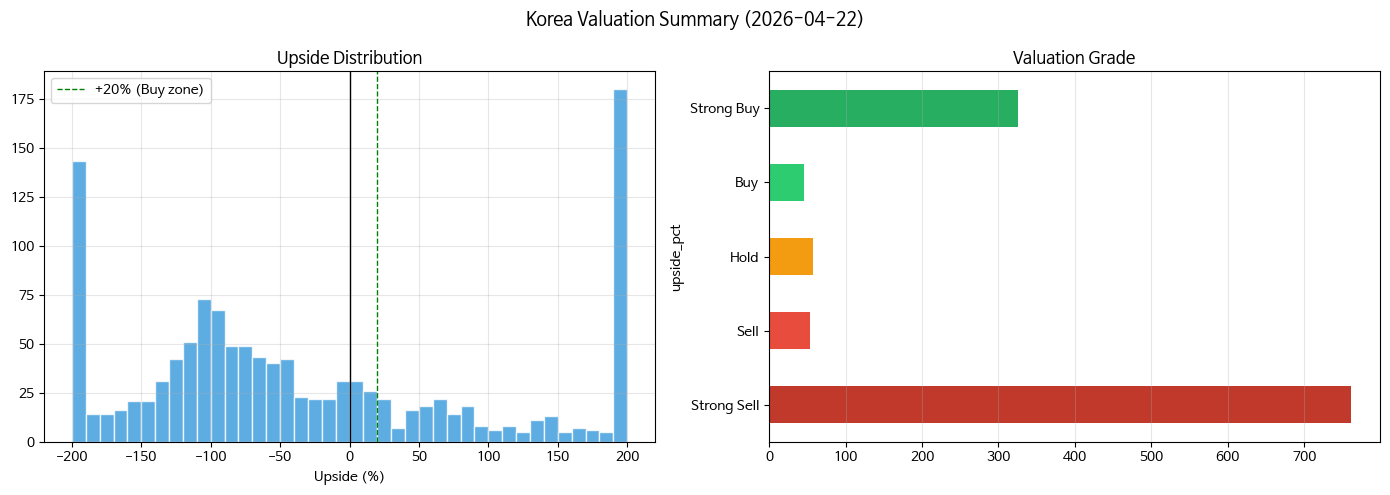


[종목별 평가 이력 예시 — 삼성전자]


,run_date,n_quarters,target_price,current_price,upside_pct,discount_rate,g_terminal,enterprise_value
0,2026-04-22,8,264506.108573,216000.0,22.456532,0.114188,0.025,1.528383e+15


In [39]:
# ── 7-1. DB 현황 (날짜별 평가 기록) ─────────────────────────
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT DATE(date) AS run_date,
                   COUNT(DISTINCT ticker) AS tickers,
                   COUNT(*) AS total_rows,
                   AVG(target_price) AS avg_tp,
                   AVG(upside_pct) AS avg_upside,
                   AVG(discount_rate) AS avg_wacc
            FROM {TABLE_RESULT}
            GROUP BY DATE(date)
            ORDER BY run_date DESC LIMIT 10
        """)
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 70)
print(f"[DB 현황] {TABLE_RESULT}")
print("=" * 70)
display(_summary)

# ── 7-2. 최신 평가일 기준 업사이드 분포 ─────────────────────
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(f"SELECT MAX(date) AS m FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["m"]
        if max_date:
            cur.execute(f"""
                SELECT ticker,
                       MAX(target_price) AS target_price,
                       MAX(current_price) AS current_price,
                       MAX(upside_pct) AS upside_pct,
                       MAX(discount_rate) AS wacc,
                       MAX(g_terminal) AS g_terminal,
                       MAX(moat_label) AS moat
                FROM {TABLE_RESULT}
                WHERE date=%s AND target_price IS NOT NULL AND current_price IS NOT NULL
                GROUP BY ticker
                ORDER BY upside_pct DESC
            """, (max_date,))
            results_df = pd.DataFrame(cur.fetchall())
        else:
            results_df = pd.DataFrame()
finally:
    conn.close()

if max_date and not results_df.empty:
    print(f"\n[최신 평가일: {max_date}] 총 {len(results_df)}개")
    print("\n🔼 업사이드 TOP 20")
    display(results_df.head(20))
    print("\n🔽 다운사이드 TOP 20")
    display(results_df.tail(20))

    # 분포 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Korea Valuation Summary ({max_date})", fontsize=13)
    ax = axes[0]
    upside_clean = results_df["upside_pct"].dropna().clip(-200, 200)
    ax.hist(upside_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(20, color="green", lw=1, ls="--", label="+20% (Buy zone)")
    ax.set_title("Upside Distribution")
    ax.set_xlabel("Upside (%)"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    grade = pd.cut(results_df["upside_pct"],
                   bins=[-np.inf, -20, 0, 20, 50, np.inf],
                   labels=["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"])
    grade.value_counts().sort_index().plot(
        kind="barh", ax=ax,
        color=["#c0392b", "#e74c3c", "#f39c12", "#2ecc71", "#27ae60"])
    ax.set_title("Valuation Grade"); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("[INFO] 데이터 없음 — Cell 6 배치 실행 필요")

# ── 7-3. 종목별 평가일자 추이 (호영님 요청 #12) ───────────
print("\n[종목별 평가 이력 예시 — 삼성전자]")
hist = get_evaluation_history("A005930", db_info, table_name=TABLE_RESULT)
display(hist)


a## Cell 8 · 데이터 품질 진단 (호영님 결정 #5)

배치 실행 시 모든 fallback 사용 내역이 `korea_valuation_quality_log` 에 저장됩니다.
이 셀에서 어떤 종목이 어떤 데이터 문제가 있었는지 확인할 수 있습니다.

**용도:**
1. **fallback_zero 종목 식별** → 보조항목 컬럼 결측 → 결과 신뢰도 낮음
2. **fallback_median 종목 식별** → OLS 부적합 → 모델 적합도 미달
3. **missing 종목 식별** → 핵심항목 결측으로 평가 자체 실패
4. **R² 분포 확인** → 회귀 적합도 전반적 진단


In [40]:
# ── 데이터 품질 진단 ─────────────────────────────────────

conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        # 1) 최신 평가일의 status별 분포
        cur.execute(f"""
            SELECT field, status, COUNT(*) AS cnt,
                   AVG(r_squared) AS avg_r2,
                   AVG(value) AS avg_value
            FROM {TABLE_QUALITY}
            WHERE date = (SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='FCFF_DCF')
              AND model='FCFF_DCF'
            GROUP BY field, status
            ORDER BY field, status
        """)
        df_status = pd.DataFrame(cur.fetchall())

        # 2) fallback 비율 높은 항목 TOP 10
        cur.execute(f"""
            SELECT field,
                   SUM(status='ok') AS ok_cnt,
                   SUM(status='fallback_median') AS fb_med,
                   SUM(status='fallback_zero') AS fb_zero,
                   SUM(status='missing') AS miss,
                   COUNT(*) AS total,
                   ROUND(SUM(status LIKE 'fallback%')/COUNT(*)*100, 1) AS fb_pct
            FROM {TABLE_QUALITY}
            WHERE date = (SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='FCFF_DCF')
              AND model='FCFF_DCF'
            GROUP BY field
            ORDER BY fb_pct DESC
        """)
        df_field = pd.DataFrame(cur.fetchall())

        # 3) 가장 문제 많은 종목 TOP 10
        cur.execute(f"""
            SELECT ticker,
                   SUM(status LIKE 'fallback%') AS fallback_cnt,
                   SUM(status='missing') AS miss_cnt,
                   GROUP_CONCAT(DISTINCT field ORDER BY field SEPARATOR ',') AS issues
            FROM {TABLE_QUALITY}
            WHERE date = (SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='FCFF_DCF')
              AND model='FCFF_DCF'
              AND (status LIKE 'fallback%' OR status='missing')
            GROUP BY ticker
            HAVING fallback_cnt + miss_cnt >= 3
            ORDER BY (fallback_cnt + miss_cnt*2) DESC
            LIMIT 30
        """)
        df_problem_tickers = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 70); print("[1] 항목별 status 분포 (최신 평가일)"); print("=" * 70)
display(df_status)

print("\n" + "=" * 70); print("[2] 항목별 fallback 비율 (TOP)"); print("=" * 70)
display(df_field)

print("\n" + "=" * 70); print("[3] 데이터 문제가 많은 종목 TOP 30 (수동 확인 권장)"); print("=" * 70)
display(df_problem_tickers)

# ── 4) 특정 종목의 모든 진단 항목 조회 함수 ──────────────
def inspect_ticker_quality(ticker: str, run_date: str = None) -> pd.DataFrame:
    """특정 종목의 데이터 품질 상세 (해당 평가일 또는 최신)."""
    tk = to_dg_ticker(ticker)
    conn = get_pymysql_conn(db_info)
    try:
        with conn.cursor() as cur:
            if run_date:
                cur.execute(f"""SELECT date, field, status, n_obs, value, r_squared, note
                                  FROM {TABLE_QUALITY}
                                  WHERE ticker=%s AND date=%s AND model='FCFF_DCF'
                                  ORDER BY field""", (tk, run_date))
            else:
                cur.execute(f"""SELECT date, field, status, n_obs, value, r_squared, note
                                  FROM {TABLE_QUALITY}
                                  WHERE ticker=%s AND model='FCFF_DCF'
                                    AND date = (SELECT MAX(date) FROM {TABLE_QUALITY}
                                                 WHERE ticker=%s AND model='FCFF_DCF')
                                  ORDER BY field""", (tk, tk))
            return pd.DataFrame(cur.fetchall())
    finally:
        conn.close()

# 사용 예시
print("\n[예시] 삼성전자 데이터 품질 상세")
display(inspect_ticker_quality("A005930"))


OperationalError: (1247, "Reference 'fallback_cnt' not supported (reference to group function)")